In [1]:
!pip install openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.3/251.3 kB 1.6 MB/s eta 0:00:0000:0100:01


In [2]:
!pip install anndata==0.8.0

In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from sklearn.neighbors import KernelDensity
import time
import dill
import pickle
from scipy.spatial import distance
import os
import scipy
from tqdm import tqdm
import networkx as nx
from itertools import groupby

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print(nx.__version__)

2.6.3


In [2]:
Fullorthotable = pd.read_csv('../../OTO_star_nothreshold_6species_ohnlogs_expressionthresh_07232026.tsv', delimiter = '\t',index_col = 'MM')

In [3]:
Fullorthotable.index.value_counts()[Fullorthotable.index.value_counts() > 1]

Series([], Name: MM, dtype: int64)

In [4]:
sam_mg = SAM()
sam_mg.load_data('../../Active_SAM_joined/SAM_Allen_Institute_allhypo_01272026.h5ad')
gene_dict_mg = {}
for i in range(len(sam_mg.adata.var_names)):
    gene_dict_mg[sam_mg.adata.var_names[i]] = i

In [5]:
sam_mo = SAM()
sam_mo.load_data('../../Active_SAM_joined/SAM_MO_soupx_plus5_cleaned_03122025.h5ad')
gene_dict_mo = {}
for i in range(len(sam_mo.adata.var_names)):
    gene_dict_mo[sam_mo.adata.var_names[i]] = i

In [6]:
sam_cj = SAM()
sam_cj.load_data('../../Active_SAM_joined/SAM_CJ_joined_v2_cleaned_03122025.h5ad')
gene_dict_cj = {}
for i in range(len(sam_cj.adata.var_names)):
    gene_dict_cj[sam_cj.adata.var_names[i]] = i

In [7]:
sam_ac= SAM()
sam_ac.load_data('../../Active_SAM_joined/SAM_AC_ncbi_soupx_cleaned_03122025.h5ad')
gene_dict_ac = {}
for i in range(len(sam_ac.adata.var_names)):
    gene_dict_ac[sam_ac.adata.var_names[i]] = i

In [8]:
sam_xt = SAM()
sam_xt.load_data('../../Active_SAM_joined/SAM_XT_joined_Slc17a6_cleaned_03122205.h5ad')
gene_dict_xt = {}
for i in range(len(sam_xt.adata.var_names)):
    gene_dict_xt[sam_xt.adata.var_names[i]] = i

In [9]:
sam_dr = SAM()
sam_dr.load_data('../../Active_SAM_joined/SAM_DR_ncbi_joined_cleaned_07172026.h5ad')
gene_dict_dr = {}
for i in range(len(sam_dr.adata.var_names)):
    gene_dict_dr[sam_dr.adata.var_names[i]] = i

In [10]:
TF = pd.read_csv('../../Fin_TF_06012026.csv')
TF_set = set(TF['0'])

In [15]:
overall_TF_set = set(Fullorthotable.index) & TF_set

In [16]:
mg_TF_cl = [item for item in overall_TF_set]
mo_TF_cl = [Fullorthotable.loc[item,'MO'] for item in overall_TF_set]
cj_TF_cl = [Fullorthotable.loc[item,'CJ'] for item in overall_TF_set]
ac_TF_cl = [Fullorthotable.loc[item,'AC'] for item in overall_TF_set]
xt_TF_cl = [Fullorthotable.loc[item,'XT'] for item in overall_TF_set]
dr_TF_cl = [Fullorthotable.loc[item,'DR'] for item in overall_TF_set]

In [17]:
with open('../../parent_dict.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

In [23]:
sam_mo.adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_counts', 'n_genes',
       'key', 'subclass_id_label_mapping', 'subclass_id_label_lc',
       'leiden_clusters', 'subclass_id_label_mapping_nounlabeled',
       'neurotransmitter', 'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled',
       'leiden_clusters_formarkers', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'NN', 'ss_subclass',
       'ss_subclass_nounlabeled', 'ss_subclass_nounlabeled_03102026',
       'ss_subclass_nounlabeled_03102026_crossed', 'neurotransmitter_v2'],
      dtype='object')

In [24]:
for item in sam_mo.adata.obs['ss_subclass_nounlabeled_03102026'].unique():
    if item[-2:] == 'NN':
        parent_dict[item] = 'not hypo'
    if item[:2] == 'mo':
        parent_dict[item] = 'hypo'
    if item[:2] == 'mg':
        parent_dict[item] = 'hypo'
    if item[:2] == 'xt':
        parent_dict[item] = 'hypo'
    if item[:2] == 'ri':
        parent_dict[item] = 'hypo'
    if item[:2] == 'ac':
        parent_dict[item] = 'hypo'
    if item[:2] == 'cj':
        parent_dict[item] = 'hypo'
    if item[:2] == 'dr':
        parent_dict[item] = 'hypo'
    if item[:2] == 'mv':
        parent_dict[item] = 'hypo'
    if item[:2] == 'cc':
        parent_dict[item] = 'hypo'
    if item[:2] == 'rv':
        parent_dict[item] = 'hypo'
    if item[:2] == 'ri':
        parent_dict[item] = 'hypo'
        
parent_dict['not hypo'] = 'not hypo'
parent_dict['Unlabeled'] = 'Unlabeled'
parent_dict['hypo'] = 'hypo'
parent_dict['Unknown'] = 'hypo'
parent_dict['Unknwon_2'] = 'hypo'
parent_dict['Non neuron'] = 'not hypo'

In [36]:
sam_mo.adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_counts', 'n_genes',
       'key', 'subclass_id_label_mapping', 'subclass_id_label_lc',
       'leiden_clusters', 'subclass_id_label_mapping_nounlabeled',
       'neurotransmitter', 'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled',
       'leiden_clusters_formarkers', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'NN', 'ss_subclass',
       'ss_subclass_nounlabeled', 'ss_subclass_nounlabeled_03102026',
       'ss_subclass_nounlabeled_03102026_crossed', 'neurotransmitter_v2'],
      dtype='object')

In [39]:
ctl = [i for i in sam_mo.adata.obs['ss_subclass_nounlabeled_03102026'].unique() if parent_dict[parent_dict[i]] == 'hypo']

In [40]:
ctl

['mo_5',
 'mo_0',
 '108 ARH-PVp Tbx3 Gaba',
 'mo_23',
 '128 VMH Fezf1 Glut',
 '140 PMd-LHA Foxb1 Glut',
 '097 PVHd-SBPV Six3 Prox1 Gaba',
 '107 DMH Hmx2 Gaba',
 '101 ZI Pax6 Gaba',
 '086 MPO-ADP Lhx8 Gaba',
 'mo_6',
 'mg_077_106',
 '135 STN-PSTN Pitx2 Glut',
 '133 PVH-SO-PVa Otp Glut',
 '092 TMv-PMv Tbx3 Hist-Gaba',
 '103 PVHd-DMH Lhx6 Gaba',
 '132 AHN-RCH-LHA Otp Fezf1 Glut',
 '099 SBPV-PVa Six6 Satb2 Gaba',
 '127 DMH-LHA Vgll2 Glut',
 'mo_9',
 'mo_14',
 '106 PVpo-VMPO-MPN Hmx2 Gaba',
 'mo_4',
 '144 MM Foxb1 Glut',
 '129 VMH Nr5a1 Glut',
 '116 AVPV-MEPO-SFO Tbr1 Glut',
 '098 AHN-SBPV-PVHd Pdrm12 Gaba',
 'mo_2',
 '105 TMd-DMH Foxd2 Gaba',
 '143 MM-ant Foxb1 Glut',
 'mo_10',
 '100 AHN Onecut3 Gaba',
 '136 PMv-TMv Pitx2 Glut',
 '093 RT-ZI Gnb3 Gaba',
 '123 DMH Nkx2-4 Glut',
 'mo_11',
 '117 LHA Barhl2 Glut',
 '134 PH-ant-LHA Otp Bsx Glut',
 '119 SI-MA-LPO-LHA Skor1 Glut',
 '118 ADP-MPO Trp73 Glut',
 '076 MEA-BST Lhx6 Nfib Gaba',
 '124 MPN-MPO-PVpo Hmx2 Glut',
 '139 PH-LHA Foxb1 Glut',
 '1

In [41]:
missing_mg = []
exp = sam_mg.adata.X.A
for item in mg_TF_cl:
    if item in gene_dict_mg.keys():
        ind = gene_dict_mg[item]
        if np.sum(exp[:,ind]) > 0:
            missing_mg.append(False)
        else:
            missing_mg.append(True)
    else:
        missing_mg.append(True)
print('fin mg')
        
missing_mo = []
hypo_mo = [parent_dict[parent_dict[i]] == 'hypo' for i in sam_mo.adata.obs['ss_subclass_nounlabeled_03102026']]
exp_mo = sam_mo.adata.X.A[hypo_mo,:]
for item in mo_TF_cl:
    if item in gene_dict_mo.keys():
        ind = gene_dict_mo[item]
        if np.sum(exp_mo[:,ind]) > 0:
            missing_mo.append(False)
        else:
            missing_mo.append(True)
    else:
        missing_mo.append(True)
print('fin mo')
        
missing_cj = []
hypo_cj = [parent_dict[parent_dict[i]] == 'hypo' for i in sam_cj.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn']]
exp_cj = sam_cj.adata.X.A[hypo_cj,:]
for item in cj_TF_cl:
    if item in gene_dict_cj.keys():
        ind = gene_dict_cj[item]
        if np.sum(exp_cj[:,ind]) > 0:
            missing_cj.append(False)
        else:
            missing_cj.append(True)
    else:
        missing_cj.append(True)
print('fin cj')
        
missing_ac = []
hypo_ac = [parent_dict[parent_dict[i]] == 'hypo' for i in sam_ac.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn']]
exp_ac = sam_ac.adata.X.A[hypo_ac,:]
for item in ac_TF_cl:
    if item in gene_dict_ac.keys():
        ind = gene_dict_ac[item]
        if np.sum(exp_ac[:,ind]) > 0:
            missing_ac.append(False)
        else:
            missing_ac.append(True)
    else:
        missing_ac.append(True)
print('fin ac')
        
missing_xt = []
hypo_xt = [parent_dict[parent_dict[i]] == 'hypo' for i in sam_xt.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn']]
exp_xt = sam_xt.adata.X.A[hypo_xt,:]
for item in xt_TF_cl:
    if item in gene_dict_xt.keys():
        ind = gene_dict_xt[item]
        if np.sum(exp_xt[:,ind]) > 0:
            missing_xt.append(False)
        else:
            missing_xt.append(True)
    else:
        missing_xt.append(True)
print('fin xt')

missing_dr = []
hypo_dr = [parent_dict[parent_dict[i]] == 'hypo' for i in sam_dr.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn']]
exp_dr = sam_dr.adata.X.A[hypo_dr,:]
for item in dr_TF_cl:
    if item in gene_dict_dr.keys():
        ind = gene_dict_dr[item]
        if np.sum(exp_dr[:,ind]) > 0:
            missing_dr.append(False)
        else:
            missing_dr.append(True)
    else:
        missing_dr.append(True)
print('fin dr')

fin mg
fin mo
fin cj
fin ac
fin xt
fin dr


In [42]:
fin_ind = []
for i in range(len(missing_mg)):
    if int(missing_mg[i]) + int(missing_cj[i]) + int(missing_ac[i]) + int(missing_mo[i]) + int(missing_xt[i]) + int(missing_dr[i]) == 0:
        fin_ind.append(i)

In [43]:
len(fin_ind)

439

In [44]:
mg_TF_fin = [mg_TF_cl[i] for i in fin_ind]
mo_TF_fin = [mo_TF_cl[i] for i in fin_ind]
cj_TF_fin = [cj_TF_cl[i] for i in fin_ind]
ac_TF_fin = [ac_TF_cl[i] for i in fin_ind]
xt_TF_fin = [xt_TF_cl[i] for i in fin_ind]
dr_TF_fin = [dr_TF_cl[i] for i in fin_ind]

In [45]:
oto_TF_mapping = pd.DataFrame(data = [mg_TF_fin,
                     mo_TF_fin,
                     cj_TF_fin,
                     ac_TF_fin,
                     xt_TF_fin,
                     dr_TF_fin,],
             index = ['Mouse TF name','Vole TF name','Quail TF name','Anole TF name','Xenopus TF name','Zebrafish TF name']).T

In [46]:
oto_TF_mapping.to_csv('../../TF_oto_mapping_allorgs_Fig3D_07242026.csv')

In [47]:
sam_mo.adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_counts', 'n_genes',
       'key', 'subclass_id_label_mapping', 'subclass_id_label_lc',
       'leiden_clusters', 'subclass_id_label_mapping_nounlabeled',
       'neurotransmitter', 'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled',
       'leiden_clusters_formarkers', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'NN', 'ss_subclass',
       'ss_subclass_nounlabeled', 'ss_subclass_nounlabeled_03102026',
       'ss_subclass_nounlabeled_03102026_crossed', 'neurotransmitter_v2'],
      dtype='object')

In [48]:
sam_mo.adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_counts', 'n_genes',
       'key', 'subclass_id_label_mapping', 'subclass_id_label_lc',
       'leiden_clusters', 'subclass_id_label_mapping_nounlabeled',
       'neurotransmitter', 'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled',
       'leiden_clusters_formarkers', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'NN', 'ss_subclass',
       'ss_subclass_nounlabeled', 'ss_subclass_nounlabeled_03102026',
       'ss_subclass_nounlabeled_03102026_crossed', 'neurotransmitter_v2'],
      dtype='object')

In [49]:
exp = sam_mg.adata.X.A
exp_mini = exp[:,[gene_dict_mg[j] for j in [mg_TF_cl[i] for i in fin_ind]]]
exp_mini_ct = np.zeros((sam_mg.adata.obs['subclass_id_label'].nunique(),exp_mini.shape[1]))
ctl = sam_mg.adata.obs['subclass_id_label'].unique()
for i in range(len(ctl)):
    exp_mini_ct[i,:] = np.average(exp_mini[sam_mg.adata.obs['subclass_id_label'] == ctl[i],:], axis = 0)
    
exp_mo = sam_mo.adata.X.A
exp_mini_mo = exp_mo[:,[gene_dict_mo[j] for j in [mo_TF_cl[i] for i in fin_ind]]]
ctl = [i for i in sam_mo.adata.obs['ss_subclass_nounlabeled_03102026'].unique() if parent_dict[parent_dict[i]] == 'hypo']
exp_mini_ct_mo = np.zeros((len(ctl),exp_mini_mo.shape[1]))
for i in range(len(ctl)):
    exp_mini_ct_mo[i,:] = np.average(exp_mini_mo[sam_mo.adata.obs['ss_subclass_nounlabeled_03102026'] == ctl[i],:], axis = 0)
    
exp_cj = sam_cj.adata.X.A
exp_mini_cj = exp_cj[:,[gene_dict_cj[j] for j in [cj_TF_cl[i] for i in fin_ind]]]
ctl = [i for i in sam_cj.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
exp_mini_ct_cj = np.zeros((len(ctl),exp_mini_cj.shape[1]))
for i in range(len(ctl)):
    exp_mini_ct_cj[i,:] = np.average(exp_mini_cj[sam_cj.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'] == ctl[i],:], axis = 0)
    
exp_ac = sam_ac.adata.X.A
exp_mini_ac = exp_ac[:,[gene_dict_ac[j] for j in [ac_TF_cl[i] for i in fin_ind]]]
ctl = [i for i in sam_ac.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
exp_mini_ct_ac = np.zeros((len(ctl),exp_mini_ac.shape[1]))
for i in range(len(ctl)):
    exp_mini_ct_ac[i,:] = np.average(exp_mini_ac[sam_ac.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'] == ctl[i],:], axis = 0)
    
exp_xt = sam_xt.adata.X.A
exp_mini_xt = exp_xt[:,[gene_dict_xt[j] for j in [xt_TF_cl[i] for i in fin_ind]]]
ctl = [i for i in sam_xt.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
exp_mini_ct_xt = np.zeros((len(ctl),exp_mini_xt.shape[1]))
for i in range(len(ctl)):
    exp_mini_ct_xt[i,:] = np.average(exp_mini_xt[sam_xt.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'] == ctl[i],:], axis = 0)
    
exp_dr = sam_dr.adata.X.A
exp_mini_dr = exp_dr[:,[gene_dict_dr[j] for j in [dr_TF_cl[i] for i in fin_ind]]]
ctl = [i for i in sam_dr.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
exp_mini_ct_dr = np.zeros((len(ctl),exp_mini_dr.shape[1]))
for i in range(len(ctl)):
    exp_mini_ct_dr[i,:] = np.average(exp_mini_dr[sam_dr.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'] == ctl[i],:], axis = 0)

In [50]:
pearson_corr_mg = np.zeros((exp_mini_ct.shape[1],exp_mini_ct.shape[1]))
for i in tqdm(range(exp_mini_ct.shape[1])):
    for j in range(exp_mini_ct.shape[1]):
        pearson_corr_mg[i][j] = stats.pearsonr(exp_mini_ct[:,i],exp_mini_ct[:,j])[0]
        
pearson_corr_mo = np.zeros((exp_mini_ct_mo.shape[1],exp_mini_ct_mo.shape[1]))
for i in tqdm(range(exp_mini_ct_mo.shape[1])):
    for j in range(exp_mini_ct_mo.shape[1]):
        pearson_corr_mo[i][j] = stats.pearsonr(exp_mini_ct_mo[:,i],exp_mini_ct_mo[:,j])[0]
        
pearson_corr_cj = np.zeros((exp_mini_ct_cj.shape[1],exp_mini_ct_cj.shape[1]))
for i in tqdm(range(exp_mini_ct_cj.shape[1])):
    for j in range(exp_mini_ct_cj.shape[1]):
        pearson_corr_cj[i][j] = stats.pearsonr(exp_mini_ct_cj[:,i],exp_mini_ct_cj[:,j])[0]
        
pearson_corr_ac = np.zeros((exp_mini_ct_ac.shape[1],exp_mini_ct_ac.shape[1]))
for i in tqdm(range(exp_mini_ct_ac.shape[1])):
    for j in range(exp_mini_ct_ac.shape[1]):
        pearson_corr_ac[i][j] = stats.pearsonr(exp_mini_ct_ac[:,i],exp_mini_ct_ac[:,j])[0]
        
pearson_corr_xt = np.zeros((exp_mini_ct_xt.shape[1],exp_mini_ct_xt.shape[1]))
for i in tqdm(range(exp_mini_ct_xt.shape[1])):
    for j in range(exp_mini_ct_xt.shape[1]):
        pearson_corr_xt[i][j] = stats.pearsonr(exp_mini_ct_xt[:,i],exp_mini_ct_xt[:,j])[0]

pearson_corr_dr = np.zeros((exp_mini_ct_dr.shape[1],exp_mini_ct_dr.shape[1]))
for i in tqdm(range(exp_mini_ct_dr.shape[1])):
    for j in range(exp_mini_ct_dr.shape[1]):
        pearson_corr_dr[i][j] = stats.pearsonr(exp_mini_ct_dr[:,i],exp_mini_ct_dr[:,j])[0]

100%|█████████████████████████████████████████| 439/439 [00:10<00:00, 43.63it/s]


In [51]:
spearman_corr_mg = np.zeros((exp_mini_ct.shape[1],exp_mini_ct.shape[1]))
for i in tqdm(range(exp_mini_ct.shape[1])):
    for j in range(exp_mini_ct.shape[1]):
        spearman_corr_mg[i][j] = stats.spearmanr(exp_mini_ct[:,i],exp_mini_ct[:,j])[0]
        
spearman_corr_mo = np.zeros((exp_mini_ct_mo.shape[1],exp_mini_ct_mo.shape[1]))
for i in tqdm(range(exp_mini_ct_mo.shape[1])):
    for j in range(exp_mini_ct_mo.shape[1]):
        spearman_corr_mo[i][j] = stats.spearmanr(exp_mini_ct_mo[:,i],exp_mini_ct_mo[:,j])[0]
        
spearman_corr_cj = np.zeros((exp_mini_ct_cj.shape[1],exp_mini_ct_cj.shape[1]))
for i in tqdm(range(exp_mini_ct_cj.shape[1])):
    for j in range(exp_mini_ct_cj.shape[1]):
        spearman_corr_cj[i][j] = stats.spearmanr(exp_mini_ct_cj[:,i],exp_mini_ct_cj[:,j])[0]
        
spearman_corr_ac = np.zeros((exp_mini_ct_ac.shape[1],exp_mini_ct_ac.shape[1]))
for i in tqdm(range(exp_mini_ct_ac.shape[1])):
    for j in range(exp_mini_ct_ac.shape[1]):
        spearman_corr_ac[i][j] = stats.spearmanr(exp_mini_ct_ac[:,i],exp_mini_ct_ac[:,j])[0]
        
spearman_corr_xt = np.zeros((exp_mini_ct_xt.shape[1],exp_mini_ct_xt.shape[1]))
for i in tqdm(range(exp_mini_ct_xt.shape[1])):
    for j in range(exp_mini_ct_xt.shape[1]):
        spearman_corr_xt[i][j] = stats.spearmanr(exp_mini_ct_xt[:,i],exp_mini_ct_xt[:,j])[0]

spearman_corr_dr = np.zeros((exp_mini_ct_dr.shape[1],exp_mini_ct_dr.shape[1]))
for i in tqdm(range(exp_mini_ct_dr.shape[1])):
    for j in range(exp_mini_ct_dr.shape[1]):
        spearman_corr_dr[i][j] = stats.spearmanr(exp_mini_ct_dr[:,i],exp_mini_ct_dr[:,j])[0]

100%|█████████████████████████████████████████| 439/439 [01:42<00:00,  4.30it/s]


In [52]:
pearson_corr_mg = pd.DataFrame(data = pearson_corr_mg, index = [mg_TF_cl[i] for i in fin_ind], columns = [mg_TF_cl[i] for i in fin_ind])
pearson_corr_mo = pd.DataFrame(data = pearson_corr_mo, index = [mo_TF_cl[i] for i in fin_ind], columns = [mo_TF_cl[i] for i in fin_ind])
pearson_corr_cj = pd.DataFrame(data = pearson_corr_cj, index = [cj_TF_cl[i] for i in fin_ind], columns = [cj_TF_cl[i] for i in fin_ind])
pearson_corr_ac = pd.DataFrame(data = pearson_corr_ac, index = [ac_TF_cl[i] for i in fin_ind], columns = [ac_TF_cl[i] for i in fin_ind])
pearson_corr_xt = pd.DataFrame(data = pearson_corr_xt, index = [xt_TF_cl[i] for i in fin_ind], columns = [xt_TF_cl[i] for i in fin_ind])
pearson_corr_dr = pd.DataFrame(data = pearson_corr_dr, index = [dr_TF_cl[i] for i in fin_ind], columns = [dr_TF_cl[i] for i in fin_ind])

In [53]:
spearman_corr_mg = pd.DataFrame(data = spearman_corr_mg, index = [mg_TF_cl[i] for i in fin_ind], columns = [mg_TF_cl[i] for i in fin_ind])
spearman_corr_mo = pd.DataFrame(data = spearman_corr_mo, index = [mo_TF_cl[i] for i in fin_ind], columns = [mo_TF_cl[i] for i in fin_ind])
spearman_corr_cj = pd.DataFrame(data = spearman_corr_cj, index = [cj_TF_cl[i] for i in fin_ind], columns = [cj_TF_cl[i] for i in fin_ind])
spearman_corr_ac = pd.DataFrame(data = spearman_corr_ac, index = [ac_TF_cl[i] for i in fin_ind], columns = [ac_TF_cl[i] for i in fin_ind])
spearman_corr_xt = pd.DataFrame(data = spearman_corr_xt, index = [xt_TF_cl[i] for i in fin_ind], columns = [xt_TF_cl[i] for i in fin_ind])
spearman_corr_dr = pd.DataFrame(data = spearman_corr_dr, index = [dr_TF_cl[i] for i in fin_ind], columns = [dr_TF_cl[i] for i in fin_ind])

In [54]:
fin_array_pearson = np.maximum.reduce([np.minimum.reduce([pearson_corr_mo,pearson_corr_cj,pearson_corr_ac,pearson_corr_xt,pearson_corr_dr]),
                                np.minimum.reduce([pearson_corr_mg,pearson_corr_cj,pearson_corr_ac,pearson_corr_xt,pearson_corr_dr]),
                                np.minimum.reduce([pearson_corr_mg,pearson_corr_mo,pearson_corr_ac,pearson_corr_xt,pearson_corr_dr]),
                                np.minimum.reduce([pearson_corr_mg,pearson_corr_mo,pearson_corr_cj,pearson_corr_xt,pearson_corr_dr]),
                                np.minimum.reduce([pearson_corr_mg,pearson_corr_mo,pearson_corr_cj,pearson_corr_ac,pearson_corr_dr]),
                                np.minimum.reduce([pearson_corr_mg,pearson_corr_mo,pearson_corr_cj,pearson_corr_ac,pearson_corr_xt])])

In [55]:
pearson_max_array = np.maximum.reduce([pearson_corr_mg,pearson_corr_mo,pearson_corr_cj,pearson_corr_ac,pearson_corr_xt,pearson_corr_dr])

In [56]:
fin_array_spearman = np.maximum.reduce([
    np.minimum.reduce([spearman_corr_mo, spearman_corr_cj, spearman_corr_ac, spearman_corr_xt, spearman_corr_dr]),
    np.minimum.reduce([spearman_corr_mg, spearman_corr_cj, spearman_corr_ac, spearman_corr_xt, spearman_corr_dr]),
    np.minimum.reduce([spearman_corr_mg, spearman_corr_mo, spearman_corr_ac, spearman_corr_xt, spearman_corr_dr]),
    np.minimum.reduce([spearman_corr_mg, spearman_corr_mo, spearman_corr_cj, spearman_corr_xt, spearman_corr_dr]),
    np.minimum.reduce([spearman_corr_mg, spearman_corr_mo, spearman_corr_cj, spearman_corr_ac, spearman_corr_dr]),
    np.minimum.reduce([spearman_corr_mg, spearman_corr_mo, spearman_corr_cj, spearman_corr_ac, spearman_corr_xt])
])

In [57]:
spearman_max_array = np.maximum.reduce([spearman_corr_mg,spearman_corr_mo,spearman_corr_cj,spearman_corr_ac,spearman_corr_xt,spearman_corr_dr])

In [58]:
sam_cj.adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_genes', 'n_counts',
       'key', 'hicat_merged', 'subclass_id_label_mapping',
       'subclass_id_label_lc', 'leiden_clusters',
       'subclass_id_label_mapping_nounlabeled', 'neurotransmitter',
       'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled', 'fraction_match',
       'best_match', 'frac_match_test', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN',
       'eq_subclass_nounlabeled_nmm', 'ss_subclass', 'ss_subclass_nounlabeled',
       'ss_class', 'ss_subclass_nounlabeled_astro', 'ss_subclass_v2',
       'ss_subclass_v2_nounlabeled', 'ss_subclass_nounlabeled_nmm',
       'ss_subclass_v3_nounlabeled', 'subclass_id_label_crossed',
       'ss_subclas

In [65]:
ctl = [i for i in sam_dr.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']

In [66]:
ctl

['dr_9',
 'dr_5',
 'cj_ac_xt_dr_3',
 '111 TRS-BAC Sln Glut',
 'dr_7',
 'cj_xt_dr_1',
 'dr_20',
 'cj_ac_xt_dr_4',
 'dr_18',
 'dr_11',
 '086 MPO-ADP Lhx8 Gaba',
 'cj_ac_xt_dr_1',
 '105 TMd-DMH Foxd2 Gaba',
 'dr_16',
 'cj_xt_dr_2',
 'dr_2',
 'ac_dr_1',
 '091 ARH-PVi Six6 Dopa-Gaba',
 'dr_23',
 'dr_14',
 'dr_8',
 'dr_26',
 '077 CEA-BST Gal Avp Gaba',
 'dr_10',
 'dr_28',
 'dr_19',
 'dr_35',
 '092 TMv-PMv Tbx3 Hist-Gaba',
 'dr_34',
 'dr_31',
 '123 DMH Nkx2-4 Glut',
 '131 LHA-AHN-PVH Otp Trh Glut',
 'dr_25',
 'dr_22',
 '075 MEA-BST Lhx6 Nr2e1 Gaba',
 '133 PVH-SO-PVa Otp Glut',
 '130 LHA Pmch Glut',
 'dr_37']

In [67]:
def num_coexpressed(array,threshold):
    count = 0
    for i in range(len(array)):
        for j in range(len(array)):
            if i != j and i < j:
                if array[i,j] > threshold:
                    count += 1
    return(count)

In [76]:
thr = [.25,.3,.35,.4]
for item in thr:
    count_min = num_coexpressed(fin_array_pearson,item)
    count_max = num_coexpressed(pearson_max_array,item)
    
    print(item, count_min,count_max,round(count_min/count_max,4))

0.25 628 50422 0.0125
0.3 268 40504 0.0066
0.35 108 31597 0.0034
0.4 57 23971 0.0024


In [77]:
thr = [.25,.3,.35,.4]
for item in thr:
    count_min = num_coexpressed(fin_array_spearman,item)
    count_max = num_coexpressed(spearman_max_array,item)
    
    print(item, count_min,count_max,round(count_min/count_max,4))

0.25 831 60922 0.0136
0.3 284 45962 0.0062
0.35 93 32642 0.0028
0.4 38 22360 0.0017


In [78]:
pearson_consensus_df = pd.DataFrame(
    fin_array_pearson,
    index=[mg_TF_cl[i] for i in fin_ind],
    columns=[mg_TF_cl[i] for i in fin_ind]
)
spearman_consensus_df = pd.DataFrame(
    fin_array_spearman,
    index=[mg_TF_cl[i] for i in fin_ind],
    columns=[mg_TF_cl[i] for i in fin_ind]
)

In [83]:
pearson_consensus_df.loc['Pgr','Esr1']

0.050824080203844386

In [82]:
spearman_consensus_df.loc['Pgr','Esr1']

0.36894766871508217

In [84]:
G = nx.Graph()
for i in range(len(fin_array_pearson)):
    for j in range(len(fin_array_pearson)):
        if fin_array_pearson[i][j] > .3 and i != j:
            G.add_edge(pearson_corr_mg.index[i], pearson_corr_mg.index[j], weight = 1)

In [85]:
fin_conn_l = []
l = []
for conn in nx.connected_components(G):
    inp = []
    for item in conn:
        inp.append(item)
    fin_conn_l.append(inp)
    l.append(len(inp))

In [86]:
cc = list(nx.find_cliques(G))

In [87]:
cc = [set(i) for i in cc]

In [88]:
with open('../../Connected_components_TF_pearson_30_7242026.pkl', 'wb') as f:
    pickle.dump(fin_conn_l, f)
    
with open('../../Cliques_TF_pearson_30_07242026.pkl', 'wb') as f:
    pickle.dump(cc, f)

In [89]:
G = nx.Graph()
for i in range(len(fin_array_spearman)):
    for j in range(len(fin_array_spearman)):
        if fin_array_spearman[i][j] > .3 and i != j:
            G.add_edge(spearman_corr_mg.index[i], spearman_corr_mg.index[j], weight = 1)
fin_conn_l = []
l = []
for conn in nx.connected_components(G):
    inp = []
    for item in conn:
        inp.append(item)
    fin_conn_l.append(inp)
    l.append(len(inp))

In [90]:
cc = list(nx.find_cliques(G))

In [91]:
cc = [set(i) for i in cc]

In [92]:
with open('../../Connected_components_TF_spearman_30_07242026.pkl', 'wb') as f:
    pickle.dump(fin_conn_l, f)
    
with open('../../Cliques_TF_spearman_30_07242026.pkl', 'wb') as f:
    pickle.dump(cc, f)

In [93]:
with open('../../Cliques_TF_pearson_30_07242026.pkl', 'rb') as f:
    p = pickle.load(f)
    
with open('../../Cliques_TF_spearman_30_07242026.pkl', 'rb') as f:
    s = pickle.load(f)

In [94]:
cliques = [set(fs) for fs in {frozenset(c) for c in p + s}]
unique_cc = [c for c in cliques if not any(c < other for other in cliques)]

In [95]:
unique_cc

[{'Hdx', 'Zhx3'},
 {'Hsf1', 'Patz1', 'Zfp143'},
 {'Patz1', 'Tfcp2'},
 {'Crebl2', 'Max'},
 {'Adnp', 'Mga'},
 {'Zfp512b', 'Zfp710'},
 {'Elf2', 'Mxi1', 'Nfyc'},
 {'Ebf1', 'Ebf2', 'Ebf3'},
 {'Rbpj', 'Sp1'},
 {'Ikzf2', 'Zhx3'},
 {'Clock', 'Zfp384'},
 {'Creb1', 'Hbp1', 'Zbtb41'},
 {'Dach1', 'Dach2'},
 {'Crebrf', 'Zfp654'},
 {'Mxd4', 'Nfyb'},
 {'Adnp', 'Zfat'},
 {'Atf1', 'Tfdp1', 'Zfx'},
 {'Atf6', 'Creb1'},
 {'Nfxl1', 'Sp3'},
 {'Foxk2', 'Tcf3', 'Wiz', 'Ybx1'},
 {'Dlx1', 'Dlx2', 'Dlx5', 'Sox2'},
 {'Gata2', 'Gata3'},
 {'Rfx5', 'Xbp1'},
 {'Crem', 'Csrnp1'},
 {'Neurod6', 'Zeb2'},
 {'Nfxl1', 'Zbtb37'},
 {'Tfcp2', 'Zbtb24'},
 {'Foxn2', 'Nfyb'},
 {'Max', 'Zbtb21'},
 {'Nr2c2', 'Sp3'},
 {'Mlxip', 'Smad2'},
 {'Creb1', 'Hbp1', 'Tcf3'},
 {'Dach2', 'Tcf4'},
 {'Patz1', 'Sp3'},
 {'Rbpj', 'Vezf1', 'Zbtb41'},
 {'Gata3', 'Otx2', 'Tal1'},
 {'Barhl1', 'Ebf2', 'Ebf3', 'Foxa1', 'Pitx2'},
 {'Rorb', 'Tcf7l2'},
 {'Barhl1', 'Irx5', 'Lmx1b', 'Pitx2'},
 {'Zfp423', 'Zic2', 'Zic5'},
 {'Cdc5l', 'Clock'},
 {'Irx1', 'Irx2'},

In [96]:
order = ['Dlx1','Dlx5','Dlx6','Dlx2','Isl1',
         'Foxa1','Lmx1a','Irx6','Pitx2','Barhl1',
          'Barhl2',
         'Uncx','Lhx5','Lhx1','Otp','Sim1','Pou3f2','Sim2','Ebf3','Ebf2',
         'Tcf7l2', 'Lef1', 'Sox5', 'Sox2', 'Rorb', 'Hmx2', 
         'Nfix','Tcf4','Neurod6','Pou6f2', 'Sp9','Bcl11b','Zfhx4', 'Nr2f2',
          'Prox1', 'St18',  'Zeb2',
          'Zic1','Zic4','Zic5','Prdm16','Onecut2','Foxg1', 'Nkx2-1', 'Nr2e1',
       'Nr4a3',  'Lhx9','Lhx2','Rfx4','Eomes',
       'Tbr1',  'Trp73', 'Pax6', 'Fezf1', 'Satb2',
       'Sox14', 'Bsx', 'Tbx3',
       'Fosl2','Gli3',
       'Otx1', 'Gsc', 'Lhx8',  'Tox3',
 'Nr2f1','Ebf1','Sall3','Six6','Casz1', 'Esr2', 'Gbx2','Bnc2',
 'Emx2',
 'Esr1',
 'Glis3',
 'Hmx3',
 'Npas3',
 'Nr5a2',
 'Six3',
 'Sox6',
 'Vax1',
'Ar',
 'Arx',
 'Bcl11a',
 'Dach1',
 'Foxb1',
 'Foxo1',
 'Irx3',
 'Irx5',
 'Lmx1b',
 'Mef2c',
 'Meis1',
 'Meis2',
 'Nkx2-2',
 'Nr4a2',
 'Pbx3',
 'Prdm12',
 'Rora',
 'Sall1',
 'Tead1',
 'Zfhx3',
 'Zfp521',
 'Zfp536',
 'Zfpm2']

In [97]:
for item in unique_cc:
    if len(item & set(order))/len(item) == 1:
        print(item)

{'Ebf2', 'Ebf1', 'Ebf3'}
{'Sox2', 'Dlx1', 'Dlx5', 'Dlx2'}
{'Neurod6', 'Zeb2'}
{'Ebf2', 'Ebf3', 'Pitx2', 'Foxa1', 'Barhl1'}
{'Tcf7l2', 'Rorb'}
{'Lmx1b', 'Irx5', 'Pitx2', 'Barhl1'}
{'Nkx2-2', 'Pou3f2'}
{'St18', 'Sox5'}
{'Lmx1b', 'Lmx1a', 'Irx5', 'Pitx2', 'Foxa1'}
{'Nr2f1', 'Nr2f2'}
{'Lmx1b', 'Nr4a2', 'Irx3', 'Lmx1a', 'Irx5', 'Foxa1'}
{'Prox1', 'Tcf4', 'St18'}
{'Bcl11b', 'Bcl11a'}
{'Foxa1', 'Pitx2', 'Irx3', 'Barhl1'}
{'Lhx5', 'Tbr1'}
{'Neurod6', 'Nfix', 'Tcf4'}
{'Pitx2', 'Zfp536'}
{'Lmx1b', 'Irx5', 'Irx3', 'Barhl1'}
{'Zfhx3', 'Zfhx4'}
{'Vax1', 'Six6', 'Sox5'}
{'Zic4', 'Prdm16', 'Zic1'}
{'Foxa1', 'Irx5', 'Irx3', 'Barhl1'}
{'Tcf7l2', 'Lef1'}
{'Tbx3', 'Six6'}
{'Nr2e1', 'Prox1', 'Sox2'}
{'Sim2', 'Sim1'}
{'Lhx8', 'Sp9'}
{'Ebf3', 'Sim1'}
{'Sox2', 'Prox1', 'Dlx2', 'Dlx1'}
{'Uncx', 'Lhx5'}
{'Ebf2', 'Foxa1', 'Barhl2'}
{'Otp', 'Sim1'}
{'Isl1', 'Dlx1', 'Dlx5', 'Dlx2'}
{'Sim2', 'Ebf3'}
{'Dlx1', 'Dlx5', 'Dlx2', 'Dlx6', 'Sp9'}
{'Lhx2', 'Lhx9'}
{'Uncx', 'Ebf2', 'Pitx2', 'Ebf3'}
{'Lhx2', 'Rfx4'}
{'Lmx1b'

In [98]:
len(unique_cc)

301

In [99]:
import csv

with open('../../TF_cliques_spearman_pearson_07242026.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(unique_cc)

In [100]:
with open('../../TF_cliques_spearman_pearson_07242026.pkl', 'wb') as f:
    pickle.dump(unique_cc, f)

In [103]:
genes = ['Foxa1','Lmx1b','Irx5', 'Irx6','Pitx2','Uncx','Lhx5','Sim1','Otp','Dlx1', 'Dlx2', 'Dlx5', 'Dlx6', 'Isl1',
         'Nfix','Tcf4','Neurod6','Vax1', 'Six6', 'Sox5','Zic3','Zic5','Zic4','Prdm16','Tcf7l2', 'Rorb', 'Lef1','Lhx9','Lhx2','Rfx4',]

In [104]:
# Wrap consensus arrays in DataFrames with mouse gene names
pearson_consensus_df = pd.DataFrame(
    fin_array_pearson,
    index=[mg_TF_cl[i] for i in fin_ind],
    columns=[mg_TF_cl[i] for i in fin_ind]
)
spearman_consensus_df = pd.DataFrame(
    fin_array_spearman,
    index=[mg_TF_cl[i] for i in fin_ind],
    columns=[mg_TF_cl[i] for i in fin_ind]
)

# Subset to the hand-picked genes
pearson_sub = pearson_consensus_df.loc[genes, genes]
spearman_sub = spearman_consensus_df.loc[genes, genes]

# Combined: lower triangle (incl diagonal) = Pearson, upper triangle = Spearman
n = len(genes)
mask_upper_tri = np.triu(np.ones((n, n), dtype=bool), k=1)
combined = np.where(mask_upper_tri, spearman_sub.values, pearson_sub.values)
combined_df = pd.DataFrame(combined, index=genes, columns=genes)

In [105]:
combined_df = combined_df.loc[genes,genes]

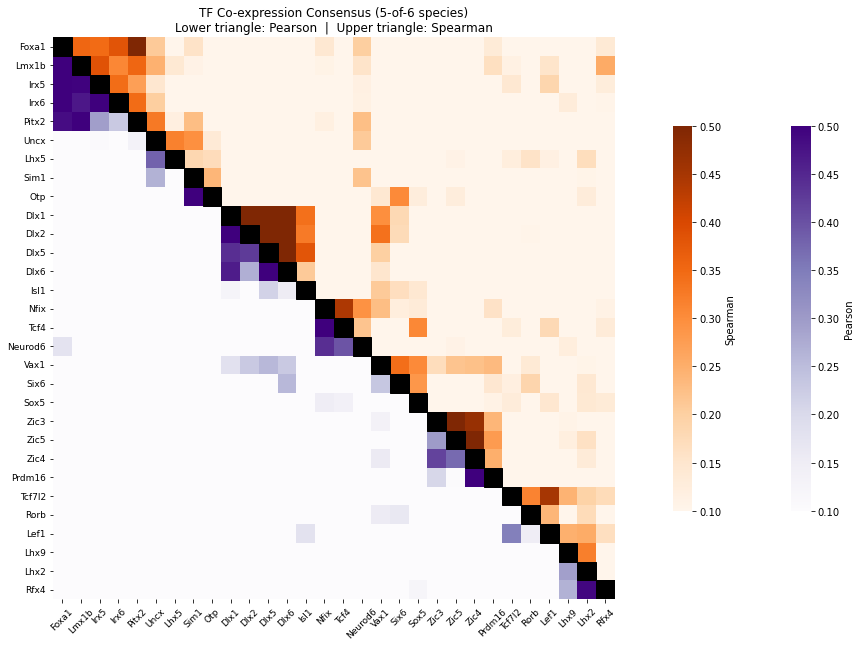

In [106]:
n = len(combined_df)
mask_upper = np.triu(np.ones((n, n), dtype=bool), k=1)  # hide upper → shows lower+diag (Pearson)
mask_lower = np.tril(np.ones((n, n), dtype=bool))        # hide lower+diag → shows upper (Spearman)

fig, ax = plt.subplots(figsize=(13, 11))

# Lower triangle + diagonal: Pearson, purple
sns.heatmap(
    combined_df,
    ax=ax,
    cmap='Purples',
    vmin=.1, vmax=.5,
    square=True,
    mask=mask_upper,
    cbar_kws={'label': 'Pearson', 'shrink': 0.5, 'pad': 0.01},
    xticklabels=True, yticklabels=True,
)

# Upper triangle: Spearman, orange
sns.heatmap(
    combined_df,
    ax=ax,
    cmap='Oranges',
    vmin=.1, vmax=.5,
    square=True,
    mask=mask_lower,
    cbar_kws={'label': 'Spearman', 'shrink': 0.5, 'pad': 0.08},
    xticklabels=True, yticklabels=True,
)

# Black diagonal
for i in range(n):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, color='black'))

ax.set_title('TF Co-expression Consensus (5-of-6 species)\nLower triangle: Pearson  |  Upper triangle: Spearman', fontsize=12)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.savefig('../../Figures/Figures_07242026/3D_TFcorr_spearman_pearson_modules_cliques_07242026.svg')
plt.savefig('../../Figures/Figures_07242026/3D_TFcorr_spearman_pearson_modules_cliques_07242026.pdf')
plt.show()

In [107]:
combined_df.to_csv('../../Figures/Figures_07242026/3D_TFcorr_spearman_pearson_modules_07242026.csv')

In [6]:
combined_df = pd.read_csv('Figures/Figures_07072026/3D_TFcorr_spearman_pearson_modules_07242026.csv', index_col = 'Unnamed: 0')